# Step 3: Convolutional Neural Networks

An MLP applied to images treats each pixel as an independent input feature.
For a 28×28 image, that's 784 inputs — and the network has no idea which pixels
are neighbors. A cat in the left corner and a cat in the right corner look completely
different to an MLP.

**Convolutional layers** encode two critical inductive biases:
1. **Local connectivity**: each neuron sees only a small patch of the input
2. **Weight sharing**: the same filter is applied at every position

These biases make the network **translation equivariant** — it detects features
regardless of where they appear — and dramatically reduce the parameter count.

**What you'll see:**
1. A convolutional layer from scratch: 2D filters, feature maps
2. Parameter count comparison: CNN vs. fully-connected
3. A simple CNN trained on MNIST
4. Visualizing what the learned filters detect

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## What a Convolution Does

A 2D convolution slides a small **filter** (kernel) across the input image.
At each position, it computes the dot product between the filter and the local patch.

```
output[i,j] = sum over (di, dj): filter[di,dj] * input[i+di, j+dj]
```

Different filters detect different features: edges, curves, textures.
The filters are **learned** by backpropagation — the network discovers which
features are useful for the task.

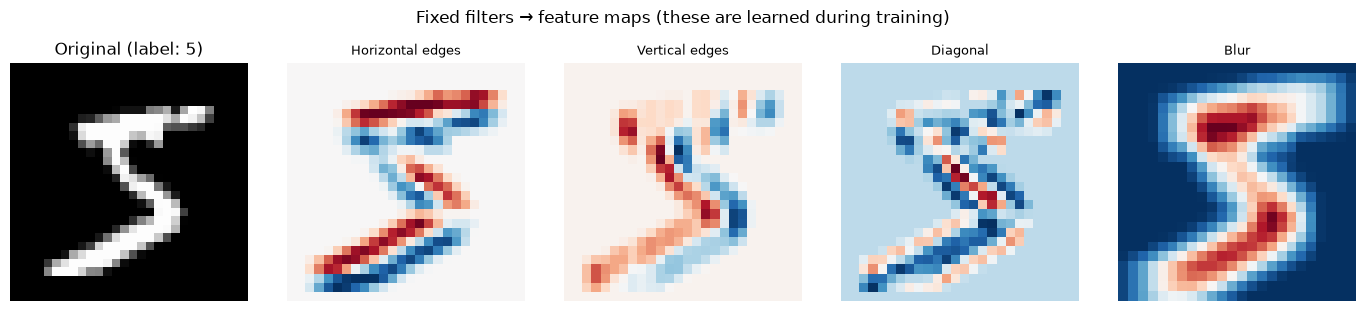

In [2]:
# Demonstrate convolution with hand-designed edge-detection filters
# (before training — these are the kinds of features CNNs learn)

def convolve2d(image, kernel):
    """Simple 2D convolution (no padding, stride 1)."""
    h, w = image.shape
    kh, kw = kernel.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)
    return output

# Load one MNIST image for demonstration
mnist_data = datasets.MNIST('./data', train=True, download=True,
                             transform=transforms.ToTensor())
sample_img, label = mnist_data[0]
img = sample_img[0].numpy()

# Classic hand-designed filters
filters = {
    'Horizontal edges': np.array([[-1,-1,-1],[0,0,0],[1,1,1]]) / 3,
    'Vertical edges':   np.array([[-1,0,1],[-1,0,1],[-1,0,1]]) / 3,
    'Diagonal':         np.array([[1,0,-1],[0,0,0],[-1,0,1]]) / 2,
    'Blur':             np.ones((5,5)) / 25,
}

fig, axes = plt.subplots(1, len(filters)+1, figsize=(14, 3))
axes[0].imshow(img, cmap='gray'); axes[0].set_title(f'Original (label: {label})')
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], filters.items()):
    feature_map = convolve2d(img, kernel)
    ax.imshow(feature_map, cmap='RdBu_r')
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.suptitle('Fixed filters → feature maps (these are learned during training)', y=1.02)
plt.tight_layout()
plt.show()

## Parameter Count: CNN vs. Fully Connected

For a 28×28 input image with 32 output feature maps:

| Layer type | Parameters |
|---|---|
| Fully connected (28²→32) | 784 × 32 + 32 = **25,120** |
| Conv2D (3×3 filter, 1→32 channels) | 3 × 3 × 1 × 32 + 32 = **320** |

A conv layer uses **78× fewer parameters** for the same output size — 
because the same filter is shared across all spatial positions.

In [3]:
# Parameter count comparison
print("=== Parameter Count Comparison ===")
print()
fc_params = 784 * 32 + 32
conv_params = 3 * 3 * 1 * 32 + 32
print(f"Fully connected (784 → 32):    {fc_params:,} parameters")
print(f"Conv2D (3×3, 1 → 32 channels): {conv_params:,} parameters")
print(f"Reduction factor:              {fc_params / conv_params:.0f}×")
print()
print("Full comparison for MNIST classifiers:")

# MLP for comparison
mlp_params = 784*128 + 128 + 128*64 + 64 + 64*10 + 10
# Simple CNN
cnn_params = (3*3*1*32+32) + (3*3*32*64+64) + (64*7*7*128+128) + (128*10+10)
print(f"MLP (784→128→64→10):    {mlp_params:,} parameters")
print(f"CNN (Conv→Conv→FC→10):  {cnn_params:,} parameters")

=== Parameter Count Comparison ===

Fully connected (784 → 32):    25,120 parameters
Conv2D (3×3, 1 → 32 channels): 320 parameters
Reduction factor:              78×

Full comparison for MNIST classifiers:
MLP (784→128→64→10):    109,386 parameters
CNN (Conv→Conv→FC→10):  421,642 parameters


## A Simple CNN for MNIST

Architecture:
```
Input (1×28×28)
  → Conv2D(1→32, 3×3) + ReLU + MaxPool(2×2)   → (32×13×13)
  → Conv2D(32→64, 3×3) + ReLU + MaxPool(2×2)  → (64×5×5)
  → Flatten → FC(1600→128) + ReLU
  → FC(128→10) + softmax
```

**ReLU** (rectified linear unit) replaces sigmoid: f(x) = max(0, x).
Its gradient is exactly 1 for positive inputs — no vanishing gradient for the forward path.

**MaxPool** reduces spatial dimensions, providing translation invariance and
reducing computation for later layers.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (1,28,28)→(32,28,28)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (32,14,14)→(64,14,14)
        self.pool  = nn.MaxPool2d(2)                              # halves spatial dims

        # Classifier head
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (32,14,14)
        x = self.pool(F.relu(self.conv2(x)))  # (64,7,7)
        x = x.flatten(1)                       # (64*7*7,)
        x = F.relu(self.fc1(self.dropout(x)))
        return self.fc2(x)                     # raw logits

model = SimpleCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print()
print(model)

Total parameters: 421,642

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [5]:
# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            correct += (model(X).argmax(1) == y).sum().item()
            total += len(y)
    return correct / total

# Training loop
train_losses, test_accs = [], []
n_epochs = 5

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    acc = evaluate(model, test_loader)
    test_accs.append(acc)
    print(f"Epoch {epoch+1}/{n_epochs} | loss: {train_losses[-1]:.4f} | test acc: {acc:.4f}")

Epoch 1/5 | loss: 0.1829 | test acc: 0.9790
Epoch 2/5 | loss: 0.0537 | test acc: 0.9856
Epoch 3/5 | loss: 0.0399 | test acc: 0.9891
Epoch 4/5 | loss: 0.0318 | test acc: 0.9902
Epoch 5/5 | loss: 0.0250 | test acc: 0.9881


In [6]:
# Visualize learned filters in conv1
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
filters = model.conv1.weight.data.cpu().numpy()  # shape: (32, 1, 3, 3)

for ax, f in zip(axes.flat, filters):
    ax.imshow(f[0], cmap='RdBu_r', vmin=-f.max(), vmax=f.max())
    ax.axis('off')

plt.suptitle('Learned conv1 filters (3×3, 32 total) — edge detectors emerge', fontsize=12)
plt.tight_layout()
plt.show()

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1200x600 with 32 Axes>

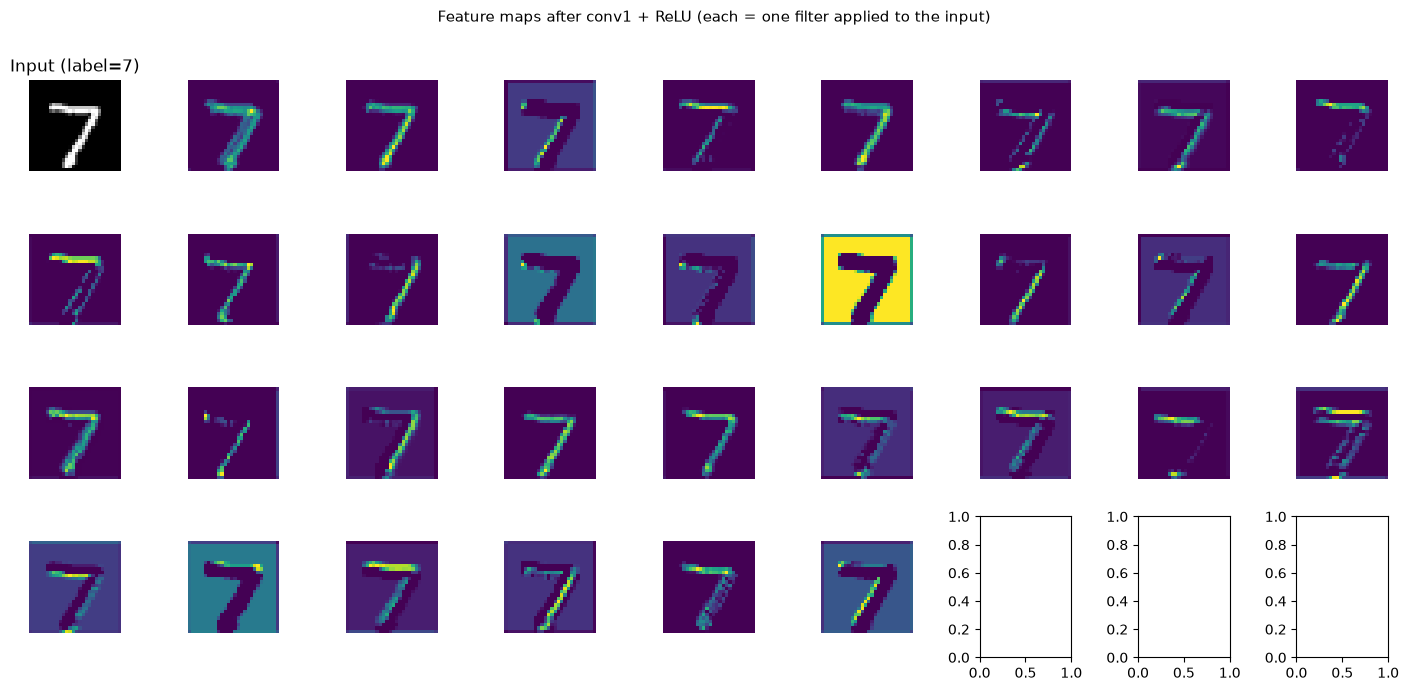

Final test accuracy: 0.9881 (98.81%)


In [7]:
# Show the feature maps for a single test image
model.eval()
test_img, test_label = test_data[0]
x = test_img.unsqueeze(0).to(device)

with torch.no_grad():
    fm1 = F.relu(model.conv1(x)).squeeze(0).cpu().numpy()  # (32, 28, 28)

fig, axes = plt.subplots(4, 9, figsize=(14, 7))
axes.flat[0].imshow(test_img[0], cmap='gray')
axes.flat[0].set_title(f'Input (label={test_label})')
axes.flat[0].axis('off')

for ax, fm in zip(axes.flat[1:], fm1):
    ax.imshow(fm, cmap='viridis')
    ax.axis('off')

plt.suptitle('Feature maps after conv1 + ReLU (each = one filter applied to the input)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Final test accuracy: {test_accs[-1]:.4f} ({test_accs[-1]*100:.2f}%)")

## Key Takeaways

| Concept | What we learned |
|---|---|
| **Local connectivity** | Each filter sees only a small patch — encodes spatial locality |
| **Weight sharing** | Same filter applied at every position — translation equivariance |
| **Feature hierarchy** | Early layers: edges → later layers: shapes → final: objects |
| **MaxPool** | Spatial downsampling; introduces translation invariance; reduces compute |
| **ReLU** | Gradient is 1 for positive inputs — far better than sigmoid for depth |
| **Parameter efficiency** | 3×3 filter with 32 outputs: 320 params vs. 25,120 for FC |

**What CNNs can't do**: they require the input to be a fixed-size grid.
Variable-length sequences (sentences, time series) need a different inductive bias.
Next: **Recurrent Neural Networks** for sequential data.